# TP 2: Regression and Cross Validation for Network Data Analysis

## 📝 Exercise 1: Linear Regression with Training and Test Data

In this exercise, you will revisit simple linear regression exercise from last week but this time with a focus on model training and evaluation using a train/test split.

### Step 1: Import Required Libraries

First, let's import the necessary libraries for data manipulation, visualization and regression modeling.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import train_test_split

### Step 2: Generate the Data

Before training a model, we need data that represents the problem we want to solve. In this lab, we use a predefined function `genSample()` to simulate synthetic data that mimics real-world behavior (e.g network-related variables).

* a) Use the provided `genSample()` function from the previous lab session to generate your dataset.

    - Choose appropriate parameters: number of samples, intercept, slope and noise level
    - Store the output into variables for input features and target labels

#### Answer:

In [2]:
## TODO:
def genSample(n, b0, b1, sigmae, xLow, xHigh, seedit=199, size=1):
    if type(seedit) == int:
        np.random.seed(seedit)
        Er = np.random.normal(mue, sigmae, n)
        x = []
        for k in range(size):
            np.random.seed(seedit + k)
            x.append(np.random.uniform(xl, xh, n))
    else:
        np.random.seed()
        Er = np.random.normal(mue, sigmae, n)
        x = []
        for k in range(size):
            np.random.seed()
            x.append(np.random.uniform(xl, xh, n))
        
    # Compute y
    y = b0 + Er
    for k in range(size):
        y += b1[k] * x[k]

    # Output
    if size == 1:
        return (x[0], y, Er)
    else:
        return (x, y, Er)

In [3]:
# Generate synthetic data
xl, xh = 0, 120
mue = 0
sigmae = 30
n, b0, b1 = 20, 2, np.array([3])
(x, y, Er) = genSample(n, b0, b1, sigmae, xl, xh, seedit=199, size=1)
print("x = ", x)
print("y = ", y)
print("Er = ", Er)

x =  [ 78.57500336 117.84471417  47.98856377 101.29831222  55.66108205
  65.38116798  74.337341    39.82041465 117.71944956  31.32134616
 112.80089673   5.39719021  50.41908488  99.59823395  69.68557585
  13.90856407  13.01791564 107.00400554  53.31687507  64.69449614]
y =  [270.96715455 345.86580798 214.62800697 250.53146256 122.96083245
 230.84184868 261.29616502 112.6821836  326.26644061 102.03533484
 389.10575263 -51.1425265  184.35715132 371.01275871 204.36454591
  24.11617543  65.50000638 310.08825187 161.57376303 235.14804055]
Er =  [ 33.24214448  -9.66833454  68.66231565 -55.3634741  -46.02241369
  32.69834474  36.28414203  -8.77906033 -28.89190806   6.07129635
  48.70306245 -69.33409712  31.09989668  70.21805685  -6.69218164
 -19.60951679  24.44625946 -12.92376476  -0.37686216  39.06455214]


### Step 3: Split the Dataset

When building predictive models, we want to know not only how well the model fits the **data it sees**, but also how well it will perform on **unseen data**. 

To do this, we split the dataset into two parts:
- A **training set** to learn from
- A **test set** to evaluate generalization

This helps prevent **overfitting** and provides a more realistic estimate of how your model will perform in production or deployment.

* b) Split the dataset into a **training set** and a **test set**.

    - Use `train_test_split()` from `sklearn.model_selection`
    - Set a test size of 20% and use a random seed for reproducibility

#### Answer:

In [4]:
## TODO:
# Convert x to a 2D array (required by scikit-learn)
X = np.array(x).reshape(-1, 1)
y = np.array(y)

# Split into training (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display the sizes of the resulting datasets
print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

Training set size: 16
Test set size: 4


### Step 4: Train the Model

Once the data is split, the next step is to fit a linear regression model using only the training set. This means the model will learn the best-fitting line by minimizing the error between the predicted and actual values on the training data. 

* c) Create and train a linear regression model using only the **training data**.

    - Use `LinearRegression()` from `sklearn.linear_model`
    - Fit the model using `.fit(...)` with your training inputs and outputs

#### Answer:

In [5]:
## TODO:
# Create the LinearRegression model
model = LinearRegression()

# Train (fit) the model using the training data
model.fit(X_train, y_train)

# Print the learned parameters
print("Intercept (β0):", model.intercept_)
print("Slope (β1):", model.coef_[0])

Intercept (β0): -2.7674084009189244
Slope (β1): 3.2175317823033214


### Step 5: Make Predictions

Once the model is trained, you can use it to predict outcomes for the test set, which simulates new, unseen data. This step evaluates how well the model generalizes.

* d) Use the trained model to predict the outputs for your test set.

    - Use the `.predict(...)` method
    - Store the predicted values for comparison with the actual test labels

#### Answer:

In [6]:
## TODO:
# Use the trained model to predict y values for X_test
y_pred = model.predict(X_test)

# Display the predictions
print("Predicted values (y_pred):", y_pred)
print("Actual values (y_test):", y_test)

Predicted values (y_pred): [250.05016219 341.52138027  41.98383854 376.40170483]
Actual values (y_test): [270.96715455 310.08825187  24.11617543 345.86580798]


### Step 6: Evaluate the Model

To measure how well the model performs, we use quantitative evaluation metrics. Two common ones are:

- **Mean Squared Error (MSE)**: Measures the average squared difference between predicted and actual values
- **R² Score**: Indicates how much of the variance in the output variable is explained by the model (closer to 1 is better)

A low MSE and high R² generally indicate a good model fit.

* e) Evaluate the accuracy of your predictions using the test data.

    - Compute **Mean Squared Error (MSE)** using `mean_squared_error(...)`
    - Compute **R² Score** using `r2_score(...)`

* f) Comment on the results.
    - Do the MSE and R² scores indicate a good fit on the test set?
    - What might cause a model to perform poorly on test data, even if it performs well on the training data?
    - Is there any indication of overfitting or underfitting?

#### Answer:

In [7]:
## TODO:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display the results
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Squared Error (MSE): 669.3141279633212
R² Score: 0.9579475123786428


1- MSE ≈ 669.3, R² ≈ 0.958 → model fits the test data well.
2- Poor test performance could occur due to overfitting, noisy data, or insufficient training samples.
3- No evidence; the model generalizes well to unseen data.

### Step 7: Visualize the Results

Visualizing your model’s predictions helps you understand how well it fits the data. A well-fitted model should have its regression line align closely with the true data points in the test set.

* g) Plot the following on a graph:

    - The original test data (as a scatter plot)
    - The model’s predicted outputs (regression line)
    - Add axis labels, a title, and a legend.

#### Answer:

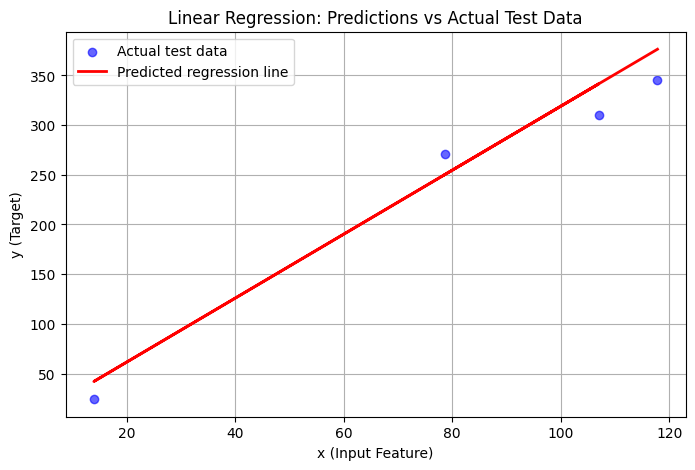

In [8]:
## TODO:
# Step 7: Visualize the Results
plt.figure(figsize=(8,5))

# Scatter plot of actual test data
plt.scatter(X_test, y_test, color='blue', alpha=0.6, label='Actual test data')

# Regression line (predicted values)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted regression line')

# Labels, title, legend
plt.xlabel("x (Input Feature)")
plt.ylabel("y (Target)")
plt.title("Linear Regression: Predictions vs Actual Test Data")
plt.legend()
plt.grid(True)
plt.show()

## 📝 Exercise 2: Polynomial Regression

In this exercise, you will explore **polynomial regression** as an extension of linear models. Polynomial regression allows us to fit more complex, non-linear relationships by using polynomial features derived from a single input variable.

We are going to generate synthetic data based on a non-linear, degree-3 polynomial function: $y = 4 + 2x + 0.5x^2 - 0.07x^3 + \epsilon$.

* The input $x$ is sampled uniformly from the interval [0, 10].
* The noise $\epsilon$ is sampled from a normal distribution with mean 0 and standard deviation $\sigma = 5$.

This is a cubic polynomial with Gaussian noise added. This equation represents the hidden ground truth that we will later try to discover using regression.

You will then fit regression models of varying polynomial degrees (from 1 to 16) and evaluate how well they approximate the true curve.

The general form of a polynomial regression model with degree $\ell$ is: $\hat{y} = \hat{\beta}_0 + \hat{\beta}_1x + \hat{\beta}_2x^2 +\ldots + \hat{\beta}_{\ell}x^{\ell}$.

Although you are still working with a single input variable $x$, transforming it into $x^2, x^3, \ldots$ means the model effectively operates in a **higher-dimensional space**.

Your task is to evaluate how different polynomial degrees affect the model's performance and generalization.

### Step 1: Generate Synthetic Data

Using the following parameters:
- $\sigma = 5$ (standard deviation of the noise)
- $n = 200$ data points
- $x \sim \text{Uniform}(0, 10)$

We generate data for:
  - Feature: $x$
  - Derived features: $x^2, x^3$
  - Noise: $\varepsilon \sim \mathcal{N}(0, \sigma^2)$
  - Target: $y = 4 + 2x + 0.5x^2 - 0.07x^3 + \varepsilon$

In [9]:
# Parameters
n = 200
b0 = 4
b1 = np.array([2,0.5,-0.07])
mue, sigmae = 0, 5
xl, xh = 0, 10

# Set random seed for reproducibility
np.random.seed(199)
Er = np.random.normal(mue, sigmae, n)
np.random.seed(199)

# Generate synthetic x values
x0 = np.random.uniform(xl,xh,n)
x = np.array([x0])
x = np.append(x,np.array([x0**2]),axis=0)
x = np.append(x,np.array([x0**3]),axis=0)


# Generate true y values using the polynomial plus noise
y = b0 + b1[0]*x[0]+ b1[1]*x[1]+ b1[2]*x[2]+Er

Then we store the data in data frames and prepare it for polynomial regression. From this point on you don't know how this data was produced, you just have the data on x and y as a data frame and are asked to do a regression.

In [10]:
dataSynth = {'x': x[0],'y': y}
df = pd.DataFrame(data=dataSynth)
df

,x,y
0,6.547917,24.421765
1,9.820393,3.953867
2,3.999047,26.961203
3,8.441526,5.177844
4,4.638424,9.378242
...,...,...
195,3.032599,8.649734
196,6.540144,19.545533
197,6.284375,20.354621
198,5.722965,23.608383


### Step 2: Split the Dataset

We have to split the data into training set and test set.

* a) Split the data into a **training set** and a **test set** using an 80/20 ratio.

    - Use `train_test_split()` from `sklearn.model_selection`
    - Set a random seed for reproducibility

#### Answer:

In [11]:
## TODO:
X = df[['x']]  # keep as a DataFrame
y = df['y']    # target variable

# Split the dataset: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (160, 1)
X_test shape: (40, 1)
y_train shape: (160,)
y_test shape: (40,)


### Step 3: Explore the Effect of Polynomial Degree

In this part, you will investigate how changing the **degree ℓ of the polynomial** affects the model’s ability to fit and generalize.

Polynomial regression is still linear regression but applied to transformed features: $\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x + \hat{\beta}_2 x^2 + \dots + \hat{\beta}_\ell x^\ell$

* b) Fit a regression model to the training data. 
* c) Predict the output on the test set.
* d) Plot the resulting regression curve along with the original data points
* e) Print the MSE and R² score for the test set
* f) Does the degree-3 polynomial fit the shape of the true curve well? Comment on R² score?

#### Answer:

In [12]:
## TODO:
# b) Fit a regression model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
# c) Predict on the test set
y_pred = model.predict(X_test)

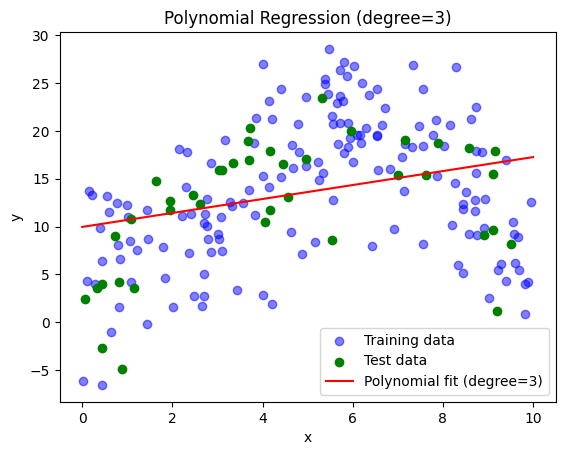

In [14]:
# d) Plot regression curve + test data
X_range = np.linspace(0, 10, 200).reshape(-1, 1)
X_range = pd.DataFrame(X_range, columns=['x'])
y_range_pred = model.predict(X_range)

plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training data')
plt.scatter(X_test, y_test, color='green', label='Test data')
plt.plot(X_range, y_range_pred, color='red', label=f'Polynomial fit (degree={3})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Regression (degree=3)')
plt.legend()
plt.show()

In [15]:
# e) MSE and R² on test set
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.3f}")

MSE: 36.94
R²: 0.136


f) Le modèle ne s’ajuste pas bien aux données (R² faible). Cela indique un underfitting, il faudrait essayer un polynôme de degré plus élevé.

### Step 4: Compare Models with Different Polynomial Degrees

In this part, you will systematically evaluate how the degree of the polynomial affects your model’s performance. 

* g) Now repeat the entire procedure for the following degrees: $\ell = 1,\ 2,\ 3,\ 6,\ 9,\ 16$

  For each degree ℓ:
  - **Hint**: You can transform the input using `PolynomialFeatures(degree=ℓ)`
  - Train the model on the training data
  - Predict on both training and test sets
  - Compute and store:
    - **Mean Squared Error (MSE)** for training and test sets
    - **R² Score** for training and test sets
  - Store all these results so you can visualize the trends across different polynomial degrees.

#### Answer:

In [16]:
## TODO:
from sklearn.preprocessing import PolynomialFeatures

# List of polynomial degrees to test
degrees = [1, 2, 3, 6, 9, 16]

# Lists to store metrics
mse_train, mse_test = [], []
r2_train, r2_test = [], []

for d in degrees:
    # Create polynomial features of degree d
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    # Train the linear regression model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Predict on training and test sets
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    # Compute MSE and R²
    mse_train.append(mean_squared_error(y_train, y_train_pred))
    mse_test.append(mean_squared_error(y_test, y_test_pred))
    r2_train.append(r2_score(y_train, y_train_pred))
    r2_test.append(r2_score(y_test, y_test_pred))

# Display the results
results = pd.DataFrame({
    'Degree': degrees,
    'Train MSE': mse_train,
    'Test MSE': mse_test,
    'Train R²': r2_train,
    'Test R²': r2_test
})

print(results)

   Degree  Train MSE   Test MSE  Train R²   Test R²
0       1  50.372000  36.944816  0.077338  0.135832
1       2  33.220737  17.374536  0.391497  0.593596
2       3  28.901817  21.822110  0.470607  0.489564
3       6  28.046841  24.725717  0.486267  0.421646
4       9  27.734670  25.290006  0.491985  0.408447
5      16  28.356403  28.608275  0.480597  0.330830


### Step 5: Visualize and Analyze the Results

Now use the collected results to analyze model performance.

* h) Plot the $MSE$ value vs. $\ell$ for the training dataset. 
* i) Plot the $MSE$ value vs. $\ell$ for the test dataset. 
* j) What do you observe?

#### Answer:

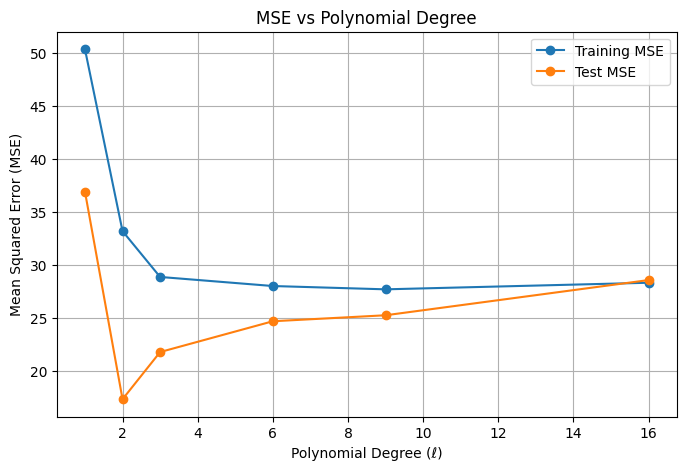

In [17]:
## TODO:
plt.figure(figsize=(8,5))
plt.plot(degrees, mse_train, marker='o', label='Training MSE')
plt.plot(degrees, mse_test, marker='o', label='Test MSE')
plt.xlabel("Polynomial Degree (ℓ)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("MSE vs Polynomial Degree")
plt.legend()
plt.grid(True)
plt.show()

j) Le MSE sur le train reste bas mais le Test MSE augmente → overfitting pour les degrés très élevés

* k) Plot the $R^2$ value vs. $\ell$ for the training dataset. 
* l) Plot the $R^2$ value vs. $\ell$ for the test dataset. 
* m) What do you observe?

#### Answer:

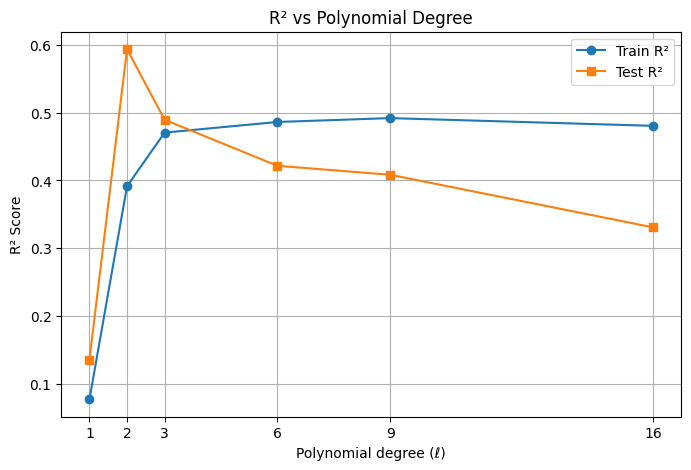

In [18]:
## TODO:
plt.figure(figsize=(8,5))
plt.plot(degrees, r2_train, marker='o', label='Train R²')
plt.plot(degrees, r2_test, marker='s', label='Test R²')
plt.xlabel("Polynomial degree (ℓ)")
plt.ylabel("R² Score")
plt.title("R² vs Polynomial Degree")
plt.xticks(degrees)
plt.grid(True)
plt.legend()
plt.show()

m) Train R² augmente légèrement avec le degré (de 0.07 à 0.49).
Test R² atteint son maximum autour de degré 2 (0.59) puis diminue avec les degrés plus élevés.

## 📝 Exercise 3: Cross Validation

In this exercise, you will explore different **cross-validation (CV)** strategies for evaluating a model’s generalization ability on small datasets.

Cross-validation helps estimate how well a model trained on one subset of data performs on unseen data.

### Step 1: Define a Toy Dataset

We will work with a very small dataset, defined as: $D_6 = \left\{(1,3),\ (2,4),\ (3,8),\ (4,9),\ (5,12),\ (7,14) \right\}$

Each pair $(x_i, y_i)$ represents an input–output example. 

* a) Store this dataset as `NumPy` arrays or a `Pandas` DataFrame.

#### Answer:

In [19]:
## TODO:
# Option 2: Using Pandas DataFrame
df = pd.DataFrame({
    'x': [1, 2, 3, 4, 5, 7],
    'y': [3, 4, 8, 9, 12, 14]
})

print(df)

   x   y
0  1   3
1  2   4
2  3   8
3  4   9
4  5  12
5  7  14


### Step 2: Cross-Validation Splits

In this part, you will explore how different cross-validation strategies divide the dataset into **training and test sets**.

For each method below, print out all train-test index splits and understand how the dataset is divided.

For each method, clearly print:
- The train indices
- The test indices

* b) Leave-One-Out Cross Validation (LOOCV):
   - Use: `LeaveOneOut()` from `sklearn.model_selection`

#### Answer:

In [20]:
## TODO:
from sklearn.model_selection import LeaveOneOut

X = df['x'].values.reshape(-1, 1)
y = df['y'].values

# Step 2b: Leave-One-Out Cross Validation
loo = LeaveOneOut()

print("LOOCV train-test splits:")
for train_index, test_index in loo.split(X):
    print("Train indices:", train_index, "Test indices:", test_index)

LOOCV train-test splits:
Train indices: [1 2 3 4 5] Test indices: [0]
Train indices: [0 2 3 4 5] Test indices: [1]
Train indices: [0 1 3 4 5] Test indices: [2]
Train indices: [0 1 2 4 5] Test indices: [3]
Train indices: [0 1 2 3 5] Test indices: [4]
Train indices: [0 1 2 3 4] Test indices: [5]


* c) 3-Fold Cross Validation:
   - Use: `KFold(n_splits=3)` from `sklearn.model_selection`

#### Answer:

In [21]:
## TODO:
from sklearn.model_selection import KFold

# Step 2c: 3-Fold Cross Validation
kf = KFold(n_splits=3, shuffle=False)

print("3-Fold CV train-test splits:")
for train_index, test_index in kf.split(X):
    print("Train indices:", train_index, "Test indices:", test_index)

3-Fold CV train-test splits:
Train indices: [2 3 4 5] Test indices: [0 1]
Train indices: [0 1 4 5] Test indices: [2 3]
Train indices: [0 1 2 3] Test indices: [4 5]


* d) Bootstrap Method:
   - Use: `Bootstrap(n_resamples=5)` from `sklearn.utils`

#### Answer:

In [22]:
## TODO:
from sklearn.utils import resample

X = np.array([1, 2, 3, 4, 5, 7])
y = np.array([3, 4, 8, 9, 12, 14])

n_resamples = 5

print("Bootstrap samples:")

for i in range(n_resamples):
    X_resampled, y_resampled = resample(X, y, replace=True, n_samples=len(X), random_state=199+i)
    
    # Find out-of-bag (OOB) indices (those not in resampled set)
    oob_mask = ~np.isin(np.arange(len(X)), [np.where(X==val)[0][0] for val in X_resampled])
    X_oob = X[oob_mask]
    y_oob = y[oob_mask]
    
    print(f"Bootstrap sample {i+1}:")
    print("X_resampled:", X_resampled)
    print("y_resampled:", y_resampled)
    print("OOB (test) X:", X_oob)
    print("OOB (test) y:", y_oob)
    print("-"*40)

Bootstrap samples:
Bootstrap sample 1:
X_resampled: [5 1 4 3 7 3]
y_resampled: [12  3  9  8 14  8]
OOB (test) X: [2]
OOB (test) y: [4]
----------------------------------------
Bootstrap sample 2:
X_resampled: [3 2 1 5 3 5]
y_resampled: [ 8  4  3 12  8 12]
OOB (test) X: [4 7]
OOB (test) y: [ 9 14]
----------------------------------------
Bootstrap sample 3:
X_resampled: [1 2 1 2 5 7]
y_resampled: [ 3  4  3  4 12 14]
OOB (test) X: [3 4]
OOB (test) y: [8 9]
----------------------------------------
Bootstrap sample 4:
X_resampled: [4 5 5 1 2 2]
y_resampled: [ 9 12 12  3  4  4]
OOB (test) X: [3 7]
OOB (test) y: [ 8 14]
----------------------------------------
Bootstrap sample 5:
X_resampled: [5 7 5 3 1 2]
y_resampled: [12 14 12  8  3  4]
OOB (test) X: [4]
OOB (test) y: [9]
----------------------------------------


### Step 3: Apply Cross-Validation for Model Evaluation

Now you will fit a linear regression model and compute the average test MSE using a specific CV strategy.

* e) Use 2-Fold Cross Validation to estimate the model’s average test error.
   - Use `cross_validate(...)` or `cross_val_score(...)` from `sklearn.model_selection`
   - Use `KFold(n_splits=2)`

Print the MSE for each fold, and compute the average test error across the two folds.

#### Answer:

In [23]:
## TODO:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, make_scorer

X = np.array([1, 2, 3, 4, 5, 7]).reshape(-1, 1)
y = np.array([3, 4, 8, 9, 12, 14])

model = LinearRegression()

kf = KFold(n_splits=2, shuffle=False)  # shuffle=False keeps original order

mse_scorer = make_scorer(mean_squared_error)

mse_scores = cross_val_score(model, X, y, cv=kf, scoring=mse_scorer)

print("MSE for each fold:", mse_scores)
print("Average test MSE:", np.mean(mse_scores))

MSE for each fold: [3.11564626 4.5       ]
Average test MSE: 3.807823129251689


### Step 4: Apply the same method to the data set below for the **TV-sales** pair:

The dataset "Advertising.csv" can be downloaded from: http://faculty.marshall.usc.edu/gareth-james/ISL/data.html

In [24]:
#directory = #your directory
prefix = "Advertising.csv"
filename1 = prefix
dataAd = np.loadtxt(filename1, delimiter=",",skiprows=1,usecols=[1,2,3,4])

In [25]:
# pandas
pdAd = pd.DataFrame(dataAd, columns=["TV","radio","newspaper","sales"])
pdAd

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [26]:
TV = pdAd.iloc[:,0].values
#radio = pdAd.iloc[:,1].values
#news = pdAd.iloc[:,2].values
sales = pdAd.iloc[:,3].values

#### **Answer:**

In [27]:
## TODO:
X = TV.reshape(-1, 1)   
y = sales     

model = LinearRegression()

kf = KFold(n_splits=2, shuffle=True, random_state=42)

mse_scorer = make_scorer(mean_squared_error)

mse_scores = cross_val_score(model, X, y, cv=kf, scoring=mse_scorer)

# Print results
print("MSE for each fold:", mse_scores)
print("Average test MSE:", np.mean(mse_scores))

MSE for each fold: [ 8.51446519 12.51875185]
Average test MSE: 10.516608520805864
